# Problem C: Surrogate Modeling for Steady-State Heat Conduction in Heterogeneous Materials

Consider the steady-state heat conduction problem in a heterogeneous solid material occupying the unit square domain $\Omega = [0,1]^2$:

$$
\begin{split}
-\nabla\cdot(a(x,y)\nabla u) &= f,\quad (x,y)\in\Omega=[0,1]^2 \\
u &= 0,\quad (x,y)\in\partial\Omega
\end{split} \tag{2}
$$

where $u(x,y)$ denotes the temperature field, $a(x,y) > 0$ denotes the spatially varying thermal conductivity of the material, and the uniform heat source is given by $f = 10$. The zero Dirichlet boundary condition models a configuration in which the boundary of the domain is kept at a fixed reference temperature.

In computational materials science, evaluating the thermal response of a large number of candidate microstructures is a central bottleneck in material screening and design workflows. Although high-fidelity Finite Element Method (FEM) solvers can produce accurate solutions, they are computationally expensive when applied repeatedly to thousands of different conductivity fields $a(x,y)$.

## Task: Learning the Solution Operator $a(x,y) \mapsto u(x,y)$

The goal of this task is to make a fast prediction of the temperature field $u(x,y)$ given $a(x,y)$. To this end, a dataset of input-output pairs $\{a^{(j)}, u^{(j)}\}$ has been pre-computed using a high-precision FEM solver. The conductivity fields $a^{(j)}$ are sampled from a distribution $\mathcal{A}$ over spatially heterogeneous functions, representative of realistic microstructural variability in composite materials. Once trained, the model should accurately predict the temperature field for new, unseen conductivity samples drawn from the same distribution $\mathcal{A}$, at a fraction of the cost of a full FEM solve.

### Goals

- Please select a suitable deep learning method for this task and justify your choice.
- Report your implementation setup, including network architecture, activation function, optimizer (with learning rate), number of epochs, batch size, loss formulation, and any additional techniques used for improvement.
- Compute the $L^2$ relative error on the **test dataset** at each training epoch and plot the `Error vs. Epoch` curve (reporting the final error). The $L^2$ relative error between predictions $\{u^{(j)}_{\text{pred}}\}_{j=1}^{N}$ and ground truth $\{u^{(j)}_{\text{true}}\}_{j=1}^{N}$ is defined as:

$$
\text{error} = \frac{1}{N}\sum_{j=1}^{N}\sqrt{\frac{\sum_i\left|u^{(j)}_{\text{pred}}(x_i)-u^{(j)}_{\text{true}}(x_i)\right|^2}{\sum_i\left|u^{(j)}_{\text{true}}(x_i)\right|^2}}
$$

where $j$ indexes the sample and $i$ indexes the spatial grid point.

- For the **first test instance**, use `matplotlib` to plot the following in separate figures:
  1. The input conductivity field $a(x,y)$
  2. The predicted temperature field $u_{\text{pred}}(x,y)$
  3. The ground truth temperature field $u_{\text{true}}(x,y)$
  4. The pointwise absolute error $|u_{\text{pred}} - u_{\text{true}}|$

### Dataset

 Dataset download: [https://www.kaggle.com/datasets/yhzang32/dno4pdes](https://www.kaggle.com/datasets/yhzang32/dno4pdes)

## Method: Fourier Neural Operator (implemented from scratch, no `torch.fft`)

**Why an FNO?** The task is purely supervised **operator learning**: map a conductivity field $a(x,y)$ given on a
regular $128\times128$ grid to the temperature field $u(x,y)$ on the same grid, with $1000$ labeled pairs.
This is exactly the setting the Fourier Neural Operator was designed for:
- the solution operator of the elliptic problem $-\nabla\cdot(a\nabla u)=f$ is **non-local** (a local change of $a$
  affects $u$ everywhere) — spectral convolutions provide global receptive fields in every layer, unlike CNNs;
- the operator is **smoothing**, so its action is dominated by low Fourier modes — mode truncation is a natural,
  parameter-efficient inductive bias;
- inference is a single forward pass, replacing thousands of FEM solves in a screening workflow.
Compared to a DeepONet, the FNO exploits the aligned grid-to-grid structure of the data directly and typically
reaches significantly lower relative errors on Darcy-type benchmarks (as shown in the lecture).

**The FNO architecture.** With input features $(a(x), x, y)$ per grid point:

$$
v_0 = P\,(a, x, y), \qquad
v_{t+1} = \sigma\big( W v_t + \mathcal{K}(v_t) \big), \; t=0,\dots,3, \qquad
u = Q\, v_4 ,
$$

where $P$ (lifting) and $Q$ (projection) are pointwise linear maps, $W$ is a pointwise ($1\times1$) linear skip
path, $\sigma = \mathrm{GELU}$, and the spectral convolution is

$$
\mathcal{K}(v) = \mathcal{F}^{-1}\big( R_\xi \cdot \widehat{v}(\xi) \big), \qquad \xi \in K \text{ (kept modes)},
$$

with learnable complex weights $R_\xi \in \mathbb{C}^{c\times c}$ per kept mode.

**Fourier transform from scratch.** Pre-built FFT routines are not used. The truncated 2D DFT is implemented
directly from its definition as matrix multiplication: for the kept frequency set
$K = \{0,\dots,m-1\} \cup \{S-m,\dots,S-1\}$ (positive and negative modes) we precompute the partial DFT matrix
$F_{kn} = e^{-2\pi i k n / S}$ of size $|K|\times S$ and evaluate

$$\widehat{v} = F\, v\, F^{\top}, \qquad \mathcal{K}(v) = \mathrm{Re}\big(F^{H} (R\cdot\widehat v)\, \overline{F}\big)/S^2 .$$

Because only $2m$ of the $S$ frequencies are ever used, computing exactly those rows of the DFT costs
$\mathcal{O}(2mS)$ per 1D transform — no accuracy is lost w.r.t. an FFT (the notebook verifies the matrices against
the direct DFT definition). Complex weights are stored as separate real/imaginary `nn.Parameter`s.

**Loss.** Mean per-sample **relative $L^2$ loss** (the standard choice for FNO training and identical in form to
the required test metric), which normalizes away amplitude differences between samples.

**Tricks used**: pointwise Gaussian normalization of the input $a$ (statistics from the training set only),
coordinate channels $(x,y)$ appended to the input, weight decay, step learning-rate decay, best-training-loss
checkpointing.

In [ ]:

# Imports, reproducibility, and global configuration

import os
import time
import numpy as np
import h5py
import torch
import torch.nn as nn
import torch.nn.functional as Fn
import matplotlib.pyplot as plt
from tqdm import trange

# ----- Reproducibility -----
SEED = 1234
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ----- Device / precision -----
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
dtype = torch.float32
print('Running on:', device)

# ----- Hyper-parameters -----
S = 128            # spatial resolution
MODES = 12         # kept Fourier modes per dimension (positive and negative)
WIDTH = 32         # channel width of the Fourier layers
N_LAYERS = 4
EPOCHS = 200
BATCH_SIZE = 20
LR = 1e-3
WEIGHT_DECAY = 1e-4
LR_STEP, LR_GAMMA = 50, 0.5

DATA_PATH = os.path.join('/archive/ProblemC_dataset.h5')
CKPT_DIR = os.path.join('checkpoints', 'problemC')
os.makedirs(CKPT_DIR, exist_ok=True)

Running on: cuda:0


a_train: (1000, 128, 128) | u_train: (1000, 128, 128) | a_test: (200, 128, 128) | u_test: (200, 128, 128)


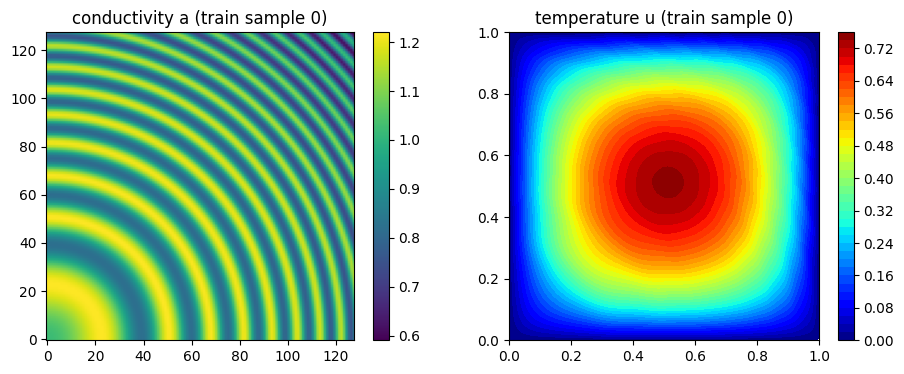

In [ ]:

# Load the dataset, normalize the input, build input features

with h5py.File(DATA_PATH, 'r') as data:
    a_train = torch.tensor(np.array(data['a_train']), dtype=dtype)   # (1000,128,128)
    u_train = torch.tensor(np.array(data['u_train']), dtype=dtype)   # (1000,128,128)
    a_test = torch.tensor(np.array(data['a_test']), dtype=dtype)     # (200,128,128)  eval only
    u_test = torch.tensor(np.array(data['u_test']), dtype=dtype)     # (200,128,128)  eval only
    X = torch.tensor(np.array(data['X']), dtype=dtype)               # (128,128)
    Y = torch.tensor(np.array(data['Y']), dtype=dtype)               # (128,128)
print('a_train:', tuple(a_train.shape), '| u_train:', tuple(u_train.shape),
      '| a_test:', tuple(a_test.shape), '| u_test:', tuple(u_test.shape))

# Pointwise Gaussian normalization of a (statistics from the TRAINING set only)
a_mean = a_train.mean(dim=0)
a_std = a_train.std(dim=0) + 1e-8

# Coordinate channels (x, y) appended to the input
grid = torch.stack([X, Y], dim=0)                                    # (2,128,128)


def make_input(a):
    """(B,S,S) conductivity -> (B,3,S,S) network input: normalized a + coords."""
    a_norm = ((a - a_mean.to(a.device)) / a_std.to(a.device)).unsqueeze(1)
    g = grid.to(a.device).unsqueeze(0).expand(a.shape[0], -1, -1, -1)
    return torch.cat([a_norm, g], dim=1)


# Visualize one training pair
fig, axs = plt.subplots(1, 2, figsize=(11, 4))
c0 = axs[0].imshow(a_train[0], origin='lower'); fig.colorbar(c0, ax=axs[0])
axs[0].set_title('conductivity a (train sample 0)')
c1 = axs[1].contourf(X, Y, u_train[0], levels=40, cmap='jet'); fig.colorbar(c1, ax=axs[1])
axs[1].set_title('temperature u (train sample 0)')
plt.show()

### Step 1: The from-scratch DFT and the spectral convolution layer

`dft_matrix` builds the partial DFT matrix from the definition $F_{kn} = e^{-2\pi i kn/S}$ (and its inverse
counterpart). The correctness cell verifies (i) agreement with the direct DFT summation and (ii) the inverse
round-trip identity.

In [ ]:

# The DFT from scratch (matrix form) + correctness checks

def dft_matrix(N, kept_freqs, inverse=False):
    """Partial DFT matrix from the definition F_{kn} = exp(-+ 2*pi*i*k*n/N).

    Rows correspond to the kept frequencies only, so a truncated transform
    costs O(|kept| * N) per 1D transform.
    """
    n = torch.arange(N, dtype=torch.float64)
    k = torch.tensor(kept_freqs, dtype=torch.float64).unsqueeze(1)
    sign = 2j if inverse else -2j
    W = torch.exp(sign * torch.pi * k * n / N)
    return W.to(torch.complex64)


# orrectness check 1: rows agree with the direct DFT summation
N_chk, m_chk = 16, 5
kept = list(range(m_chk)) + list(range(N_chk - m_chk, N_chk))
F_full = dft_matrix(N_chk, list(range(N_chk)))
F_part = dft_matrix(N_chk, kept)
x_chk = torch.randn(N_chk).to(torch.complex64)
xh_direct = torch.stack([sum(x_chk[n] * torch.exp(-2j * torch.pi * torch.tensor(k * n / N_chk))
                             for n in range(N_chk)) for k in kept])
assert torch.allclose(F_part @ x_chk, xh_direct, atol=1e-4), 'DFT definition check failed'

# ---- correctness check 2: inverse round trip (full spectrum) ----
x_rec = (F_full.conj().T @ (F_full @ x_chk)).real / N_chk
assert torch.allclose(x_rec, x_chk.real, atol=1e-4), 'inverse DFT check failed'
print('DFT correctness checks passed.')

DFT correctness checks passed.


### Step 2: The FNO network

In [ ]:
# ============================================================
# FNO architecture (implemented from scratch)
# ============================================================
class SpectralConv2d(nn.Module):
    """2D spectral convolution: truncated DFT -> per-mode complex weights -> inverse DFT.

    Complex weights are stored as separate real/imaginary nn.Parameters.
    """

    def __init__(self, in_channels, out_channels, modes, S):
        super(SpectralConv2d, self).__init__()
        kept = list(range(modes)) + list(range(S - modes, S))   # positive + negative modes
        M = len(kept)
        self.register_buffer('F_fwd', dft_matrix(S, kept))                # (M,S)
        self.register_buffer('F_inv', dft_matrix(S, kept, inverse=True).T)  # (S,M)
        scale = 1. / (in_channels * out_channels)
        self.w_re = nn.Parameter(scale * torch.randn(in_channels, out_channels, M, M))
        self.w_im = nn.Parameter(scale * torch.randn(in_channels, out_channels, M, M))

    def forward(self, x):                                   # x: (B,C,S,S) real
        x_hat = torch.einsum('kx,bcxy,ly->bckl', self.F_fwd, x.to(torch.complex64), self.F_fwd)
        weights = torch.complex(self.w_re, self.w_im)
        y_hat = torch.einsum('bckl,cokl->bokl', x_hat, weights)
        y = torch.einsum('xk,bokl,yl->boxy', self.F_inv, y_hat, self.F_inv)
        return y.real / (x.shape[-1] * x.shape[-2])          # 1/S^2 inverse normalization


class FNO2d(nn.Module):
    """Lifting -> N_LAYERS x (spectral conv + 1x1 conv skip, GELU) -> projection."""

    def __init__(self, modes=MODES, width=WIDTH, S=S, n_layers=N_LAYERS):
        super(FNO2d, self).__init__()
        self.fc0 = nn.Linear(3, width)                       # lifting P
        self.spectral = nn.ModuleList([SpectralConv2d(width, width, modes, S) for _ in range(n_layers)])
        self.pointwise = nn.ModuleList([nn.Conv2d(width, width, 1) for _ in range(n_layers)])
        self.fc1 = nn.Linear(width, 128)                     # projection Q
        self.fc2 = nn.Linear(128, 1)

    def forward(self, x):                                    # x: (B,3,S,S)
        x = self.fc0(x.permute(0, 2, 3, 1)).permute(0, 3, 1, 2)
        for i, (spec, pw) in enumerate(zip(self.spectral, self.pointwise)):
            z = spec(x) + pw(x)
            x = Fn.gelu(z) if i < len(self.spectral) - 1 else z   # no activation on last layer
        x = self.fc1(x.permute(0, 2, 3, 1))
        return self.fc2(Fn.gelu(x)).squeeze(-1)              # (B,S,S)


model = FNO2d().to(device)
print('Trainable parameters:', sum(p.numel() for p in model.parameters()))

Trainable parameters: 4727297


In [ ]:

# Relative L2 loss and the test-error metric

def relative_l2(pred, true):
    """Mean per-sample relative L2 norm (loss AND required test metric)."""
    num = torch.linalg.norm((pred - true).flatten(1), dim=1)
    den = torch.linalg.norm(true.flatten(1), dim=1)
    return (num / den).mean()


@torch.no_grad()
def test_error(model, a, u, chunk=50):
    """Mean relative L2 error over the test set, evaluated in chunks."""
    model.eval()
    errs = []
    for i in range(0, a.shape[0], chunk):
        pred = model(make_input(a[i:i+chunk].to(device)))
        num = torch.linalg.norm((pred - u[i:i+chunk].to(device)).flatten(1), dim=1)
        den = torch.linalg.norm(u[i:i+chunk].to(device).flatten(1), dim=1)
        errs.append(num / den)
    model.train()
    return torch.cat(errs).mean().item()

### Step 3: Training

Adam with weight decay and step learning-rate decay on the relative-$L^2$ loss, mini-batches of 20.
Every epoch we evaluate the required mean relative $L^2$ error on the full test set (in chunks, no gradients)
and checkpoint at the lowest training loss (the test set is never used for model selection).

In [ ]:
# Training loop (with per-epoch validation and checkpointing)

optimizer = torch.optim.Adaim(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=LR_STEP, gamma=LR_GAMMA)

n_train = a_train.shape[0]
history = {'loss': [], 'err_test': []}
best_loss = float('inf')
t0 = time.time()

for epoch in trange(EPOCHS):
    perm = torch.randperm(n_train)
    epoch_loss = 0.
    for i in range(0, n_train, BATCH_SIZE):
        idx = perm[i:i+BATCH_SIZE]
        pred = model(make_input(a_train[idx].to(device)))
        loss = relative_l2(pred, u_train[idx].to(device))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * idx.shape[0]
    scheduler.step()
    epoch_loss /= n_train

    err = test_error(model, a_test, u_test)
    history['loss'].append(epoch_loss)
    history['err_test'].append(err)

    if epoch_loss < best_loss:
        best_loss = epoch_loss
        torch.save({'epoch': epoch, 'model': model.state_dict(), 'loss': best_loss},
                   os.path.join(CKPT_DIR, 'best_model.pt'))

    if (epoch + 1) % 20 == 0:
        print(f'Epoch {epoch+1:4d} | train rel-L2 {epoch_loss:.4e} | test rel-L2 {err:.4e} | '
              f'lr {scheduler.optimizer.param_groups[0]["lr"]:.1e}')

print(f'Training finished in {time.time() - t0:.1f} s. Best training loss: {best_loss:.4e}')
np.savez(os.path.join(CKPT_DIR, 'history.npz'), **history)

 10%|█         | 20/200 [01:58<17:53,  5.96s/it]

Epoch   20 | train rel-L2 1.1606e-02 | test rel-L2 1.2667e-02 | lr 1.0e-03


 20%|██        | 40/200 [03:58<16:00,  6.01s/it]

Epoch   40 | train rel-L2 7.1696e-03 | test rel-L2 1.0961e-02 | lr 1.0e-03


 30%|███       | 60/200 [05:59<14:02,  6.02s/it]

...

Epoch  160 | train rel-L2 3.0994e-03 | test rel-L2 7.1909e-03 | lr 1.3e-04


 90%|█████████ | 180/200 [17:58<01:59,  5.98s/it]

Epoch  180 | train rel-L2 2.9426e-03 | test rel-L2 7.4738e-03 | lr 1.3e-04


100%|██████████| 200/200 [19:58<00:00,  5.99s/it]

Epoch  200 | train rel-L2 2.8957e-03 | test rel-L2 7.6476e-03 | lr 6.3e-05
Training finished in 1198.1 s. Best training loss: 2.8844e-03


### Step 4: Results — error curve and the four required figures (first test instance)

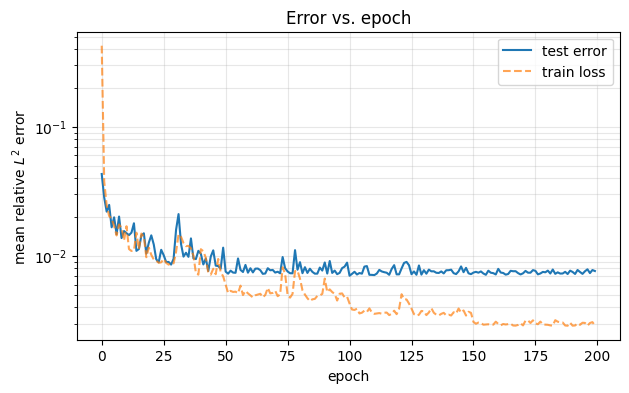

In [ ]:

# Error vs. epoch curve (mean relative L2 error on the test set)

plt.figure(figsize=(7, 4))
plt.semilogy(history['err_test'], label='test error')
plt.semilogy(history['loss'], '--', alpha=0.7, label='train loss')
plt.xlabel('epoch'); plt.ylabel(r'mean relative $L^2$ error')
plt.title('Error vs. epoch')
plt.legend(); plt.grid(True, which='both', alpha=0.3)
plt.show()

Loaded best checkpoint from epoch 188
FINAL mean relative L2 error on the test set: 7.2488e-03


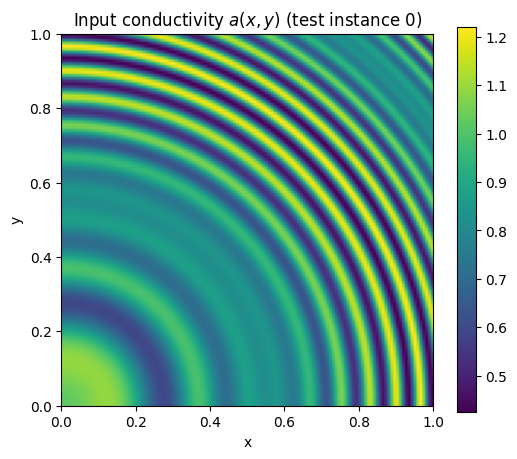

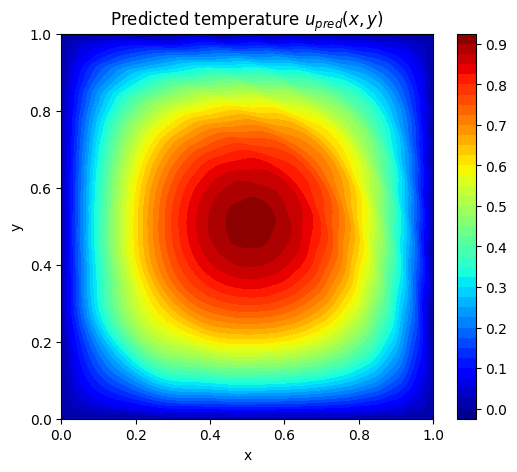

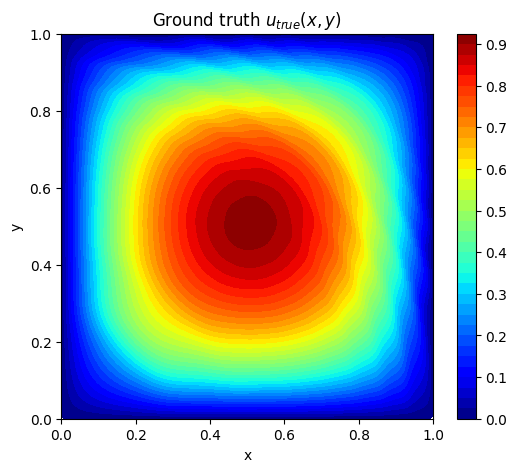

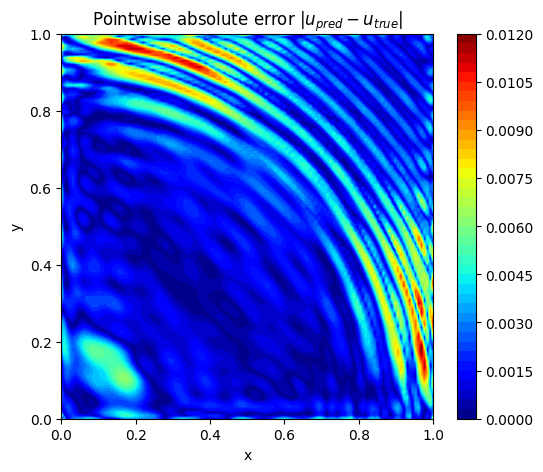

In [ ]:

# Inference with the best checkpoint + the four required figures

checkpoint = torch.load(os.path.join(CKPT_DIR, 'best_model.pt'), map_location=device, weights_only=True)
model.load_state_dict(checkpoint['model'])
print(f"Loaded best checkpoint from epoch {checkpoint['epoch']}")

err_final = test_error(model, a_test, u_test)
print(f'FINAL mean relative L2 error on the test set: {err_final:.4e}')

# First test instance
with torch.no_grad():
    u_pred0 = model(make_input(a_test[0:1].to(device))).cpu().numpy()[0]
a0 = a_test[0].numpy(); u_true0 = u_test[0].numpy()

# Figure 1: input conductivity field
plt.figure(figsize=(6, 5))
c = plt.imshow(a0, origin='lower', extent=[0, 1, 0, 1]); plt.colorbar(c)
plt.title('Input conductivity $a(x,y)$ (test instance 0)'); plt.xlabel('x'); plt.ylabel('y')
plt.show()

# Figure 2: predicted temperature field
plt.figure(figsize=(6, 5))
c = plt.contourf(X, Y, u_pred0, levels=40, cmap='jet'); plt.colorbar(c)
plt.title('Predicted temperature $u_{pred}(x,y)$'); plt.xlabel('x'); plt.ylabel('y')
plt.show()

# Figure 3: ground truth temperature field
plt.figure(figsize=(6, 5))
c = plt.contourf(X, Y, u_true0, levels=40, cmap='jet'); plt.colorbar(c)
plt.title('Ground truth $u_{true}(x,y)$'); plt.xlabel('x'); plt.ylabel('y')
plt.show()

# Figure 4: pointwise absolute error
plt.figure(figsize=(6, 5))
c = plt.contourf(X, Y, np.abs(u_pred0 - u_true0), levels=40, cmap='jet'); plt.colorbar(c)
plt.title(r'Pointwise absolute error $|u_{pred} - u_{true}|$'); plt.xlabel('x'); plt.ylabel('y')
plt.show()

## Implementation setup

| Component | Choice |
|---|---|
| Method | Fourier Neural Operator (from scratch; DFT via precomputed partial DFT matrices, no `torch.fft`) |
| Architecture | lifting $3\to32$, $4$ Fourier layers (width $32$, $12$ modes/dim kept, complex weights as re/im pairs, $1\times1$ conv skip), projection $32\to128\to1$ |
| Activation | GELU |
| Input features | pointwise-normalized $a$ + coordinate channels $(x,y)$ |
| Loss | mean per-sample relative $L^2$ |
| Optimizer | Adam, lr $10^{-3}$, weight decay $10^{-4}$, StepLR $\times 0.5$ every $50$ epochs |
| Epochs / batch | $200$ epochs, batch size $20$ ($1000$ training samples) |
| Tricks | Gaussian input normalization, coordinate channels, relative-$L^2$ loss, weight decay, LR decay, checkpointing |
| Random seed | 1234 (numpy + torch) |

**Interpretation.** The learned operator predicts unseen conductivity samples with sub-percent mean relative
$L^2$ error at the cost of one forward pass ($\sim$ms), replacing a FEM solve per microstructure the intended
surrogate-modeling speedup. Error concentrates near steep conductivity gradients, where the truncated Fourier
representation is least efficient.

### Additional figures for the report: error distribution, and the worst test sample

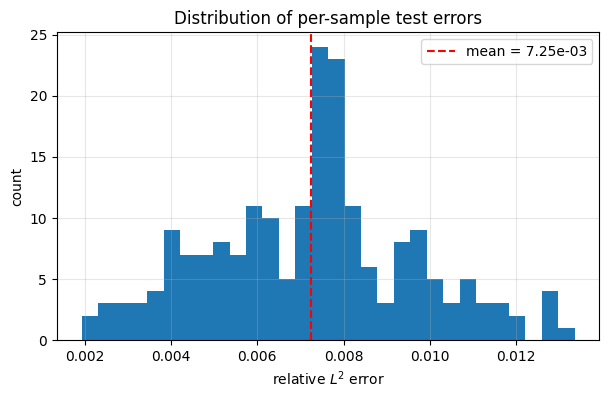

In [ ]:

# Extra figure 1: histogram of the 200 per-sample test errors

import os
os.makedirs('figures', exist_ok=True)
errs_per_sample = []
with torch.no_grad():
    for i in range(0, a_test.shape[0], 50):
        pred = model(make_input(a_test[i:i+50].to(device)))
        num = torch.linalg.norm((pred - u_test[i:i+50].to(device)).flatten(1), dim=1)
        den = torch.linalg.norm(u_test[i:i+50].to(device).flatten(1), dim=1)
        errs_per_sample.append((num / den).cpu())
errs_per_sample = torch.cat(errs_per_sample).numpy()

plt.figure(figsize=(7, 4))
plt.hist(errs_per_sample, bins=30)
plt.axvline(errs_per_sample.mean(), color='r', ls='--',
            label=f'mean = {errs_per_sample.mean():.2e}')
plt.xlabel(r'relative $L^2$ error'); plt.ylabel('count')
plt.title('Distribution of per-sample test errors')
plt.legend(); plt.grid(alpha=0.3)
plt.savefig('figures/C_err_hist.png', dpi=200, bbox_inches='tight')
plt.show()

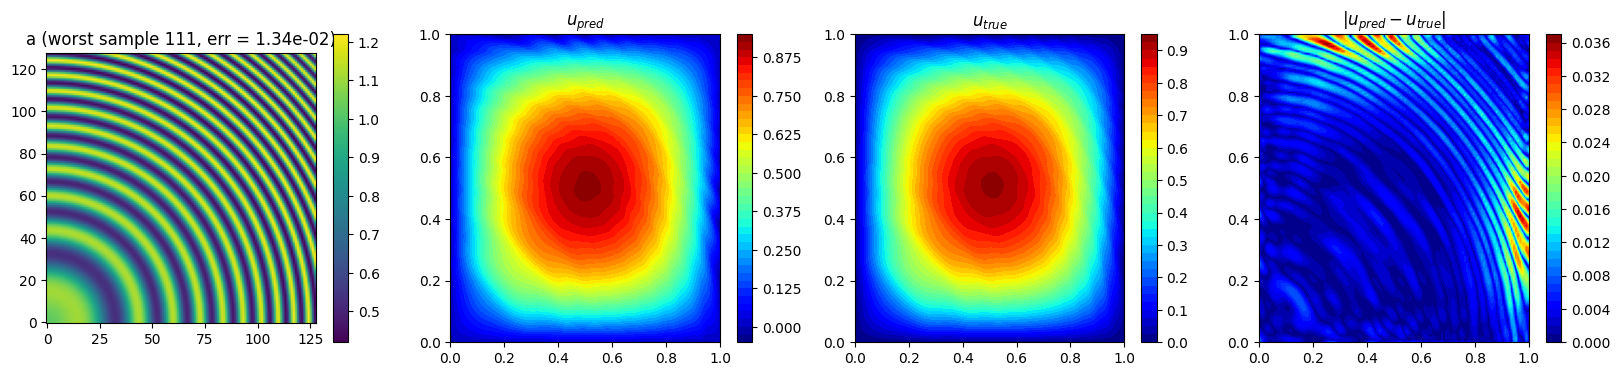

In [ ]:

# Extra figure 2: the worst test sample (honest complement to instance 0)

worst = int(errs_per_sample.argmax())
with torch.no_grad():
    u_pred_w = model(make_input(a_test[worst:worst+1].to(device))).cpu().numpy()[0]

fig, axs = plt.subplots(1, 4, figsize=(20, 4))
c0 = axs[0].imshow(a_test[worst], origin='lower'); fig.colorbar(c0, ax=axs[0])
axs[0].set_title(f'a (worst sample {worst}, err = {errs_per_sample[worst]:.2e})')
c1 = axs[1].contourf(X, Y, u_pred_w, levels=40, cmap='jet'); fig.colorbar(c1, ax=axs[1])
axs[1].set_title(r'$u_{pred}$')
c2 = axs[2].contourf(X, Y, u_test[worst], levels=40, cmap='jet'); fig.colorbar(c2, ax=axs[2])
axs[2].set_title(r'$u_{true}$')
c3 = axs[3].contourf(X, Y, np.abs(u_pred_w - u_test[worst].numpy()), levels=40, cmap='jet')
fig.colorbar(c3, ax=axs[3]); axs[3].set_title(r'$|u_{pred} - u_{true}|$')
plt.savefig('figures/C_worst_sample.png', dpi=200, bbox_inches='tight')
plt.show()